In [ ]:
  # Install required package for Excel reading
!pip install openpyxl

import pandas as pd

# Step 1: Load the Excel file
file_path = 'Vibration Data for Powerbi.xlsx'  # Replace with your file name
df = pd.read_excel(file_path)

# Step 2: Print all column names
print("Columns in the dataset:")
for col in df.columns:
    print(col)

# Step 3: Explore data shape and example rows
print(f"\nDataset shape: {df.shape}")
print("\nSample data (first 5 rows):")
print(df.head())

# Step 4: Identify time columns (representing vibration data over time)
time_cols = [col for col in df.columns if col[:4].isdigit()]  # Columns like '2019-Apr'

print(f"\nTime columns detected (vibration data columns): {len(time_cols)}")
print(time_cols)

# Step 5: Basic data cleaning for vibration data (row-wise measurements)
# Fill missing vibration values across the timeline (columns) per row
df[time_cols] = df[time_cols].apply(lambda row: row.fillna(method='ffill').fillna(method='bfill'), axis=1)

# Step 6: Check for missing values after filling
missing_after = df[time_cols].isnull().sum().sum()
print(f"\nTotal missing values in vibration data after filling: {missing_after}")

# Step 7: Inspect data types of time columns
print("\nData types of vibration/time columns:")
print(df[time_cols].dtypes.value_counts())

# Step 8: Summary statistics for vibration data across all positions and times
#print("\nSummary statistics of vibration data:")
#print(df[time_cols].describe())

# Now the data is cleaned in accordance with row-wise position/time-wise columns structure



/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
/tmp/ipython-input-2218992967.py:28: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[time_cols] = df[time_cols].apply(lambda row: row.fillna(method='ffill').fillna(method='bfill'), axis=1)


Columns in the dataset:
S.no.
Department
Equipment
Category
Criticality
Total Average
Average last 1Y
Achieved Min
Achieved Max
Avg of best 6
Standard as per ISO
Target
Last value
Outliers 2Y
Zero Outliers
Red 
Yellow 
Green
Status
2019-Apr
2019-May
2019-Jun
2019-Jul
2019-Aug
2019-Sep
2019-Oct
2019-Nov
2019-Dec
2020-Jan
2020-Feb
2020-Mar
2020-Apr
2020-May
2020-Jun
2020-Jul
2020-Aug
2020-Sep
2020-Oct
2020-Nov
2020-Dec
2021-Jan
2021-Feb
2021-Mar
2021-Apr
2021-May
2021-Jun
2021-Jul
2021-Aug
2021-Sep
2021-Oct
2021-Nov
2021-Dec
2022-Jan
2022-Feb
2022-Mar
2022-Apr
2022-May
2022-Jun
2022-July
2022-Aug
2022-Sep
2022-Oct
2022-Nov
2022-Dec
2023-Jan
2023-Feb
2023-Mar
2023-Apr
2023-May
2023-Jun
2023-Jul
2023-Aug
2023-Sep
2023-Oct
2023-Nov
2023-Dec
2024-jan
2024-Feb
2024-Mar
2024-Apr
2024-May
2024-Jun
2024-Jul
2024-Aug
2024-Sep
2024-Oct
2024-Nov
2024-Dec
2025-Jan
2025-Feb
2025-Mar
2025-Apr
2025-May
2025-June
2025-July

Dataset shape: (1458, 95)

Sample data (first 5 rows):
   S.no. Department      

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Identify time columns
time_cols = [col for col in df.columns if col[:4].isdigit()]

# Copy dataframe to avoid modifying original
df_clean = df.copy()

# Keep a counter for total outliers replaced
total_outliers = 0

for idx, row in df_clean[time_cols].iterrows():
    values = row.values.astype(float)
    Q1 = np.percentile(values, 25)
    Q3 = np.percentile(values, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (values < lower_bound) | (values > upper_bound)
    num_outliers = np.sum(mask)
    total_outliers += num_outliers
    # Replace outliers with NaN only where mask is True
    new_values = np.where(mask, np.nan, values)
    df_clean.loc[idx, time_cols] = new_values

print(f"Number of outliers replaced with NaN before filling: {total_outliers}")

# Fill missing values after outlier removal
df_clean[time_cols] = df_clean[time_cols].apply(lambda x: x.fillna(method='ffill').fillna(method='bfill'), axis=1)





Number of outliers replaced with NaN before filling: 5195


/tmp/ipython-input-27293783.py:34: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean[time_cols] = df_clean[time_cols].apply(lambda x: x.fillna(method='ffill').fillna(method='bfill'), axis=1)


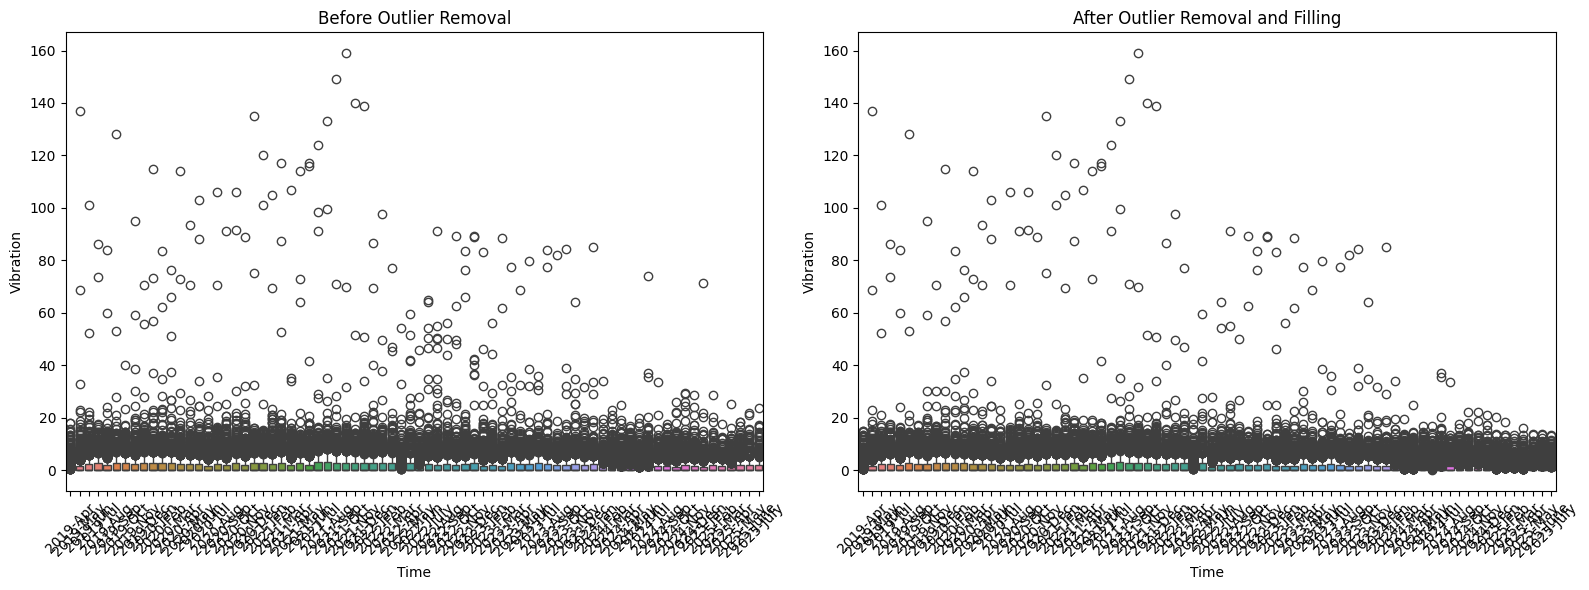

In [ ]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df[time_cols])
plt.title('Before Outlier Removal')
plt.xticks(rotation=45)
plt.xlabel('Time')
plt.ylabel('Vibration')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean[time_cols])
plt.title('After Outlier Removal and Filling')
plt.xticks(rotation=45)
plt.xlabel('Time')
plt.ylabel('Vibration')

plt.tight_layout()
plt.show()


In [ ]:
# Reasoning: pandas is chosen for robust data manipulation, numpy for fast calculations, matplotlib/seaborn for visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Excel dataset
file_path = 'Vibration Data for Powerbi.xlsx'  # update with your path
df = pd.read_excel(file_path)

# Display first few rows for inspection
print("Sample data (first 5 rows):")
print(df.head())


Sample data (first 5 rows):
   S.no. Department               Equipment  Category Criticality  \
0      1       RMHS  1.1:COAL CONVEYOR CC-1  Conveyor           A   
1      2       RMHS  1.2:COAL CONVEYOR CC-2  Conveyor           A   
2      3       RMHS  1.3:COAL CONVEYOR CC-3  Conveyor           A   
3      4       RMHS  1.4:COAL CONVEYOR CC-4  Conveyor           A   
4      5       RMHS  1.5:COAL CONVEYOR CC-5  Conveyor           A   

   Total Average  Average last 1Y  Achieved Min  Achieved Max  Avg of best 6  \
0       2.358948         2.340000         1.181          8.45       1.275167   
1       5.077136         3.357500         2.800         10.52       3.150000   
2       5.507439         5.178750         3.800          9.69       4.066667   
3       4.241803         2.450000         2.000          7.74       2.324667   
4       5.230855         5.616667         1.900         11.90       2.100000   

   ...  2024-Oct  2024-Nov  2024-Dec  2025-Jan  2025-Feb  2025-Mar  2025-Apr

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [ ]:
# Reasoning: Understanding column names, types, and missing data helps determine cleaning and feature engineering strategies.

# List all columns
print("Columns in the dataset:")
print(list(df.columns))

# Check shapes
print(f"\nDataset shape: {df.shape}")

# Print column types
print("\nColumn data types:")
print(df.dtypes)

# Missing value overview
print("\nMissing values per column:")
print(df.isnull().sum())


Columns in the dataset:
['S.no.', 'Department', 'Equipment', 'Category', 'Criticality', 'Total Average', 'Average last 1Y', 'Achieved Min', 'Achieved Max', 'Avg of best 6', 'Standard as per ISO', 'Target', 'Last value', 'Outliers 2Y', 'Zero Outliers', 'Red ', 'Yellow ', 'Green', 'Status', '2019-Apr', '2019-May', '2019-Jun', '2019-Jul', '2019-Aug', '2019-Sep', '2019-Oct', '2019-Nov', '2019-Dec', '2020-Jan', '2020-Feb', '2020-Mar', '2020-Apr', '2020-May', '2020-Jun', '2020-Jul', '2020-Aug', '2020-Sep', '2020-Oct', '2020-Nov', '2020-Dec', '2021-Jan', '2021-Feb', '2021-Mar', '2021-Apr', '2021-May', '2021-Jun', '2021-Jul', '2021-Aug', '2021-Sep', '2021-Oct', '2021-Nov', '2021-Dec', '2022-Jan', '2022-Feb', '2022-Mar', '2022-Apr', '2022-May', '2022-Jun', '2022-July', '2022-Aug', '2022-Sep', '2022-Oct', '2022-Nov', '2022-Dec', '2023-Jan', '2023-Feb', '2023-Mar', '2023-Apr', '2023-May', '2023-Jun', '2023-Jul', '2023-Aug', '2023-Sep', '2023-Oct', '2023-Nov', '2023-Dec', '2024-jan', '2024-Feb', '

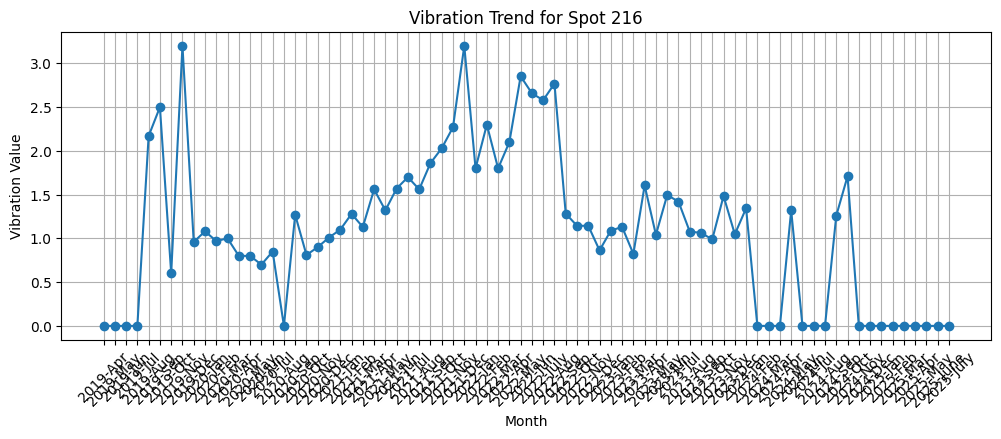

In [ ]:
# Reasoning: Visualizing time-series vibration helps detect patterns, spikes, and anomalies relevant for feature engineering and predictive modeling.

# Identify time columns (months), which typically start with a year string (e.g., '2019-')
time_cols = [col for col in df.columns if col[:4].isdigit()]

# Plot vibration over months for a random spot
random_idx = np.random.randint(0, len(df))
plt.figure(figsize=(12, 4))
plt.plot(time_cols, df.loc[random_idx, time_cols], marker='o')
plt.title(f"Vibration Trend")
plt.xlabel("Month")
plt.ylabel("Vibration Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [ ]:
# Reasoning: Statistical features (mean, std, max, min) summarize vibration history for modeling. Rolling-mean, early/late averages, and outlier flags enhance predictive power.

# Add rolling mean, std for last 3 months
df['rolling_mean_3'] = df[time_cols].iloc[:, -3:].mean(axis=1)
df['rolling_std_3'] = df[time_cols].iloc[:, -3:].std(axis=1)

# Compute statistical features for each row/spot
df['vib_mean'] = df[time_cols].mean(axis=1)
df['vib_max'] = df[time_cols].max(axis=1)
df['vib_min'] = df[time_cols].min(axis=1)
df['vib_std'] = df[time_cols].std(axis=1)

# Highlight new engineered features
print("Sample of engineered features (first 5 rows):")
print(df[['rolling_mean_3', 'rolling_std_3', 'vib_mean', 'vib_max', 'vib_min', 'vib_std']].head())



Sample of engineered features (first 5 rows):
   rolling_mean_3  rolling_std_3  vib_mean  vib_max  vib_min   vib_std
0        2.566667       0.115470  1.800250     8.45      0.0  1.356860
1        3.500000       0.264575  4.409092    10.52      0.0  2.151273
2        5.366667       0.577350  4.782776     9.69      0.0  2.108481
3        2.833333       0.416333  3.404605     7.74      0.0  2.212514
4        5.900000       0.346410  4.267276    11.90      0.0  2.729594


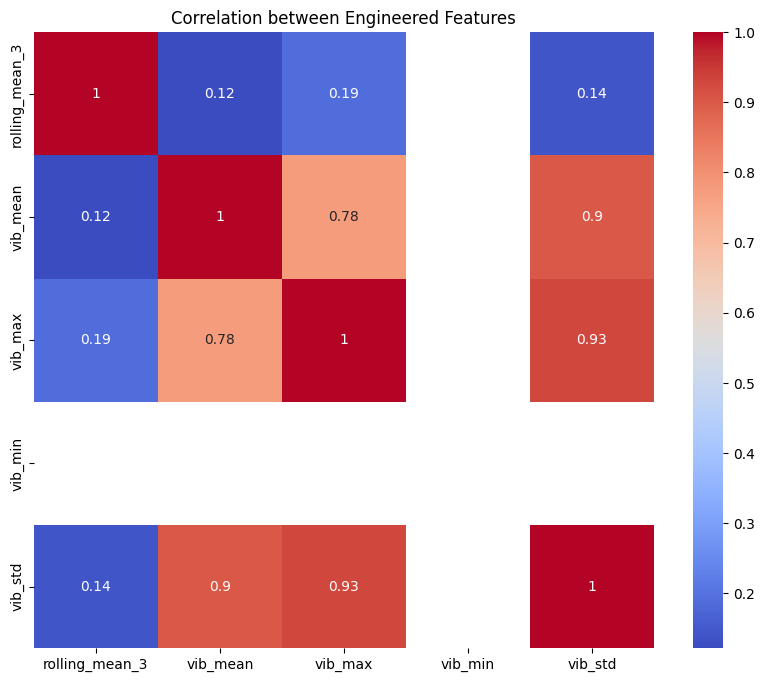

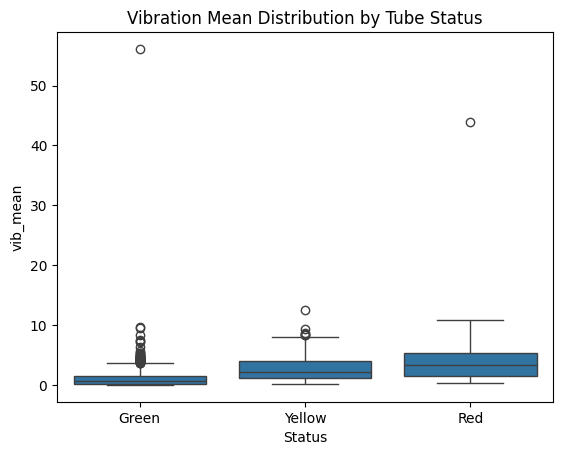

In [ ]:
# Reasoning: Correlation heatmaps and distribution plots reveal relationships between engineered features and target variables (e.g., tube status/failure).

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[['rolling_mean_3', 'vib_mean', 'vib_max', 'vib_min', 'vib_std']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Engineered Features")
plt.show()

# Distribution by Status
sns.boxplot(x='Status', y='vib_mean', data=df)
plt.title("Vibration Mean Distribution by Tube Status")
plt.show()


In [ ]:
# Reasoning: Binary target 'Status' (e.g., 'Green' vs 'Yellow') is mapped to 0/1 for supervised modeling. Feature selection leverages engineered columns.

# Encode target variable
df['Status_label'] = df['Status'].map({'Green': 0, 'Yellow': 1, 'Red': 2})
print("Status label value counts:\n", df['Status_label'].value_counts())

features = ['rolling_mean_3', 'rolling_std_3', 'vib_mean', 'vib_max', 'vib_min', 'vib_std']
X = df[features]
y = df['Status_label']

# Train-test split (chronological if possible, or random for demo)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")


Status label value counts:
 Status_label
0    1182
1     205
2      71
Name: count, dtype: int64
Training samples: 1166, Testing samples: 292


In [ ]:
# Fit with class_weight for imbalanced target
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(class_weight='balanced', max_iter=500)
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Logistic Regression balanced accuracy:", lr.score(X_test, y_test))
print("Random Forest balanced accuracy:", rf.score(X_test, y_test))


Logistic Regression balanced accuracy: 0.8013698630136986
Random Forest balanced accuracy: 0.8527397260273972


In [ ]:
# For strong imbalance, resample the minority classes
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

rf.fit(X_train_bal, y_train_bal)
print("Random Forest (SMOTE) accuracy:", rf.score(X_test, y_test))


Random Forest (SMOTE) accuracy: 0.8116438356164384


In [ ]:
from sklearn.metrics import precision_recall_curve, classification_report

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# For binary classification
if len(np.unique(y_test)) == 2:
    y_proba = rf.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, marker='.')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.show()


              precision    recall  f1-score   support

           0       0.95      0.88      0.91       237
           1       0.47      0.59      0.52        41
           2       0.20      0.29      0.24        14

    accuracy                           0.81       292
   macro avg       0.54      0.58      0.56       292
weighted avg       0.84      0.81      0.83       292



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

for name, model in [('Random Forest (weights)', rf), ('Random Forest (SMOTE)', rf_smote), ('Logistic Regression', lr)]:
    y_pred = model.predict(X_test)
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"\n{name} Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


NameError: name 'rf_smote' is not defined

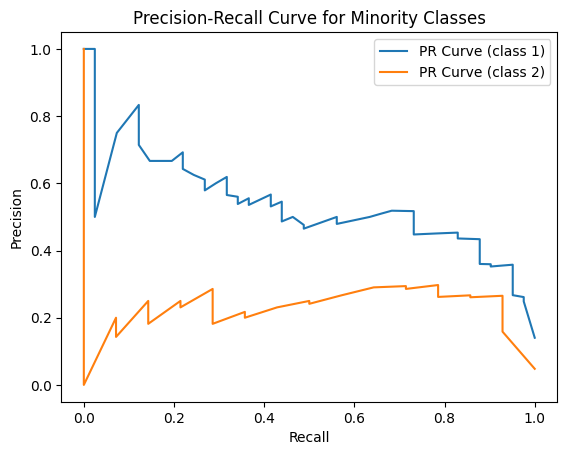

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

for class_label in [1,2]:  # Yellow, Red
    y_bin = (y_test == class_label).astype(int)
    proba = rf.predict_proba(X_test)[:, class_label]
    precision, recall, _ = precision_recall_curve(y_bin, proba)
    plt.plot(recall, precision, label=f"PR Curve (class {class_label})")
plt.title("Precision-Recall Curve for Minority Classes")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


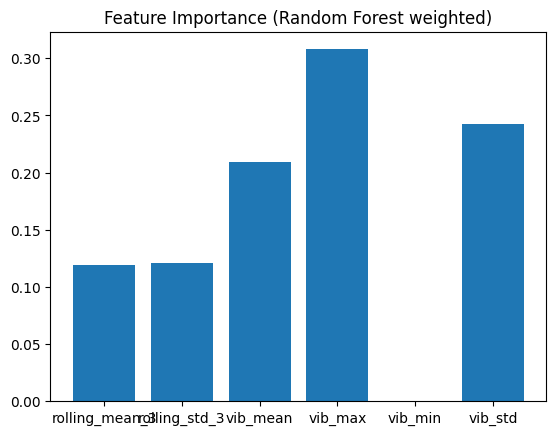

In [ ]:
importances = rf.feature_importances_
plt.bar(features, importances)
plt.title("Feature Importance (Random Forest weighted)")
plt.show()


In [ ]:
New code


In [ ]:
# Required Libraries
import pandas as pd

# Load the Data
file_path = 'conveyor_vibration_features.xlsx'  # update path as needed
df = pd.read_excel(file_path)


# Filter for 'Conveyor' category only
df = df[df['Category'] == 'Conveyor'].reset_index(drop=True)


# Preview: Show first few rows
print("First 5 rows of data:")
print(df.head())

# Show all column names
print("\nColumn names:")
print(list(df.columns))

# Show data shape (rows, columns)
print("\nData shape:")
print(df.shape)

# Check missing values
missing_summary = df.isnull().sum()
print("\nMissing values per column:")
print(missing_summary)


First 5 rows of data:
   S.no. Department               Equipment  Category Criticality  \
0      1       RMHS  1.1:COAL CONVEYOR CC-1  Conveyor           A   
1      2       RMHS  1.2:COAL CONVEYOR CC-2  Conveyor           A   
2      3       RMHS  1.3:COAL CONVEYOR CC-3  Conveyor           A   
3      4       RMHS  1.4:COAL CONVEYOR CC-4  Conveyor           A   
4      5       RMHS  1.5:COAL CONVEYOR CC-5  Conveyor           A   

   Total Average  Average last 1Y  Achieved Min  Achieved Max  Avg of best 6  \
0       2.358948         2.340000         1.181          8.45       1.275167   
1       5.077136         3.357500         2.800         10.52       3.150000   
2       5.507439         5.178750         3.800          9.69       4.066667   
3       4.241803         2.450000         2.000          7.74       2.324667   
4       5.230855         5.616667         1.900         11.90       2.100000   

   ...  rolling_std_6  rolling_mean_12  rolling_std_12  vib_mean  vib_max  \
0  ..

Time columns detected: 76

Descriptive statistics for key numerical columns:
       Total Average  Achieved Min  Achieved Max      Target  Last value  \
count     468.000000    468.000000    468.000000  468.000000  468.000000   
mean        2.655028      1.355171      5.541154    4.515068    2.406658   
std         1.942553      0.976091      6.749492    0.122793    1.894525   
min         0.000000      0.000000      0.000000    4.500000    0.000000   
25%         1.257501      0.650000      2.052500    4.500000    1.100000   
50%         2.211625      1.170500      3.955000    4.500000    2.005000   
75%         3.801877      1.900000      6.947500    4.500000    3.300000   
max        13.105349      5.700000     83.860000    6.200000   16.900000   

         2019-Apr    2019-May    2019-Jun    2019-Jul    2019-Aug  
count  468.000000  468.000000  468.000000  468.000000  468.000000  
mean     2.101776    2.087212    2.101379    2.140270    2.189374  
std      2.291824    2.414289    2

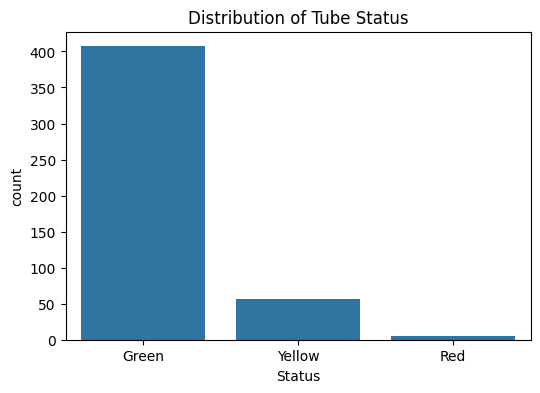

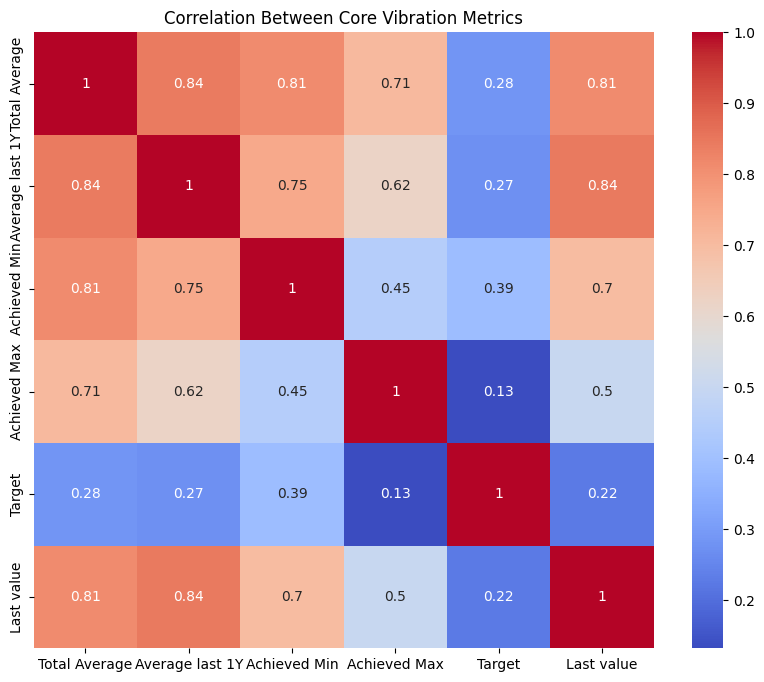

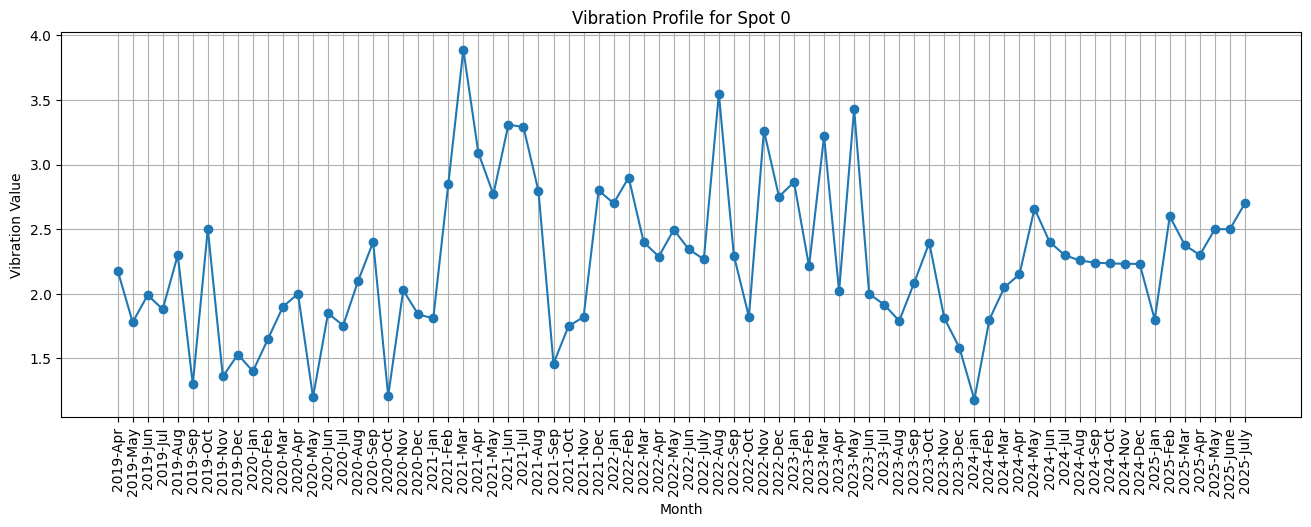

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify time columns (month-wise vibration data)
time_cols = [col for col in df.columns if col[:4].isdigit()]
print(f"Time columns detected: {len(time_cols)}")

# Basic statistics of key columns
print("\nDescriptive statistics for key numerical columns:")
print(df[['Total Average', 'Achieved Min', 'Achieved Max', 'Target', 'Last value'] + time_cols[:5]].describe())

# Distribution of Status
plt.figure(figsize=(6,4))
sns.countplot(x='Status', data=df)
plt.title("Distribution of Tube Status")
plt.show()

# Correlation heatmap for core metrics (ignoring ID/non-numeric columns)
core_metrics = ['Total Average', 'Average last 1Y', 'Achieved Min', 'Achieved Max', 'Target', 'Last value']
plt.figure(figsize=(10,8))
sns.heatmap(df[core_metrics].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Core Vibration Metrics")
plt.show()

# Time-Series Trend for a Single Tube/Spot
spot_idx = 0  # Change to any index of interest
plt.figure(figsize=(16,5))
plt.plot(time_cols, df.loc[spot_idx, time_cols], marker='o')
plt.xticks(rotation=90)
plt.xlabel("Month")
plt.ylabel("Vibration Value")
plt.title(f"Vibration Profile for Spot {spot_idx}")
plt.grid(True)
plt.show()


Outliers per spot (first 10 rows):
0    0
1    0
2    1
3    0
4    0
5    0
6    1
7    0
8    0
9    0
Name: num_outliers, dtype: int64
Flatline percent per spot (first 10 rows):
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: flatline_pct, dtype: float64


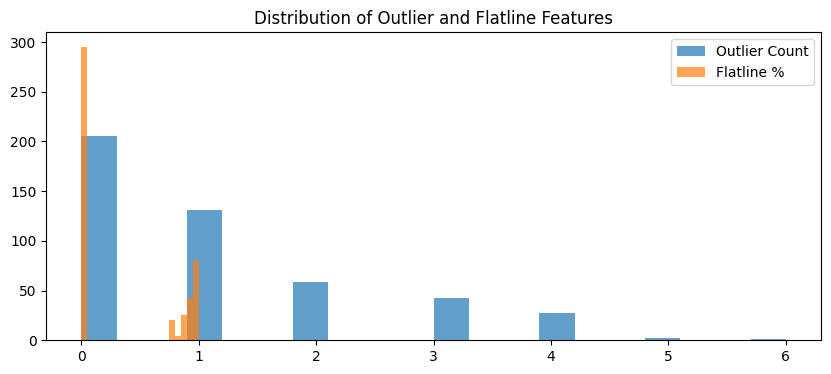

In [ ]:
import numpy as np

# Outlier detection logic (3-sigma rule example for each row/spot)
outlier_flags = []
for idx, row in df[time_cols].iterrows():
    mean = row.mean()
    std = row.std()
    # Mark outliers: any month where value > mean + 3*std or < mean - 3*std
    outliers = ((row > mean + 3*std) | (row < mean - 3*std)).sum()
    outlier_flags.append(outliers)

df['num_outliers'] = outlier_flags
print("Outliers per spot (first 10 rows):")
print(df['num_outliers'].head(10))

# Flatline detection: proportion of months where vibration = 0
flatline_percent = (df[time_cols] == 0).sum(axis=1) / len(time_cols)
df['flatline_pct'] = flatline_percent
print("Flatline percent per spot (first 10 rows):")
print(df['flatline_pct'].head(10))

# Visualize distribution of outlier/flatline features
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.hist(df['num_outliers'], bins=20, alpha=0.7, label='Outlier Count')
plt.hist(df['flatline_pct'], bins=20, alpha=0.7, label='Flatline %')
plt.legend()
plt.title("Distribution of Outlier and Flatline Features")
plt.show()


In [ ]:
from scipy.stats import linregress

def extract_trend_features(row):
    # Linear regression for degradation trend
    y = row.values
    x = np.arange(len(y))
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    return pd.Series({'trend_slope': slope, 'trend_r2': r_value**2})

# Apply to each spot
trend_df = df[time_cols].apply(extract_trend_features, axis=1)
df = pd.concat([df, trend_df], axis=1)

# Volatility: Rolling std over 12 months (1 year)
df['rolling_std_12'] = df[time_cols].rolling(window=12, axis=1).std().mean(axis=1)

# Recent recovery: ratio last 3 months' mean to previous year mean
df['recent_recovery'] = df[time_cols].iloc[:, -3:].mean(axis=1) / (df[time_cols].iloc[:, -15:-3].mean(axis=1) + 1e-6)

print("Sample advanced features (first 5 rows):")
print(df[['trend_slope', 'trend_r2', 'rolling_std_12', 'recent_recovery']].head())


Sample advanced features (first 5 rows):
   trend_slope  trend_slope  trend_r2  trend_r2  rolling_std_12  \
0     0.005316     0.005316  0.041555  0.041555        0.506543   
1    -0.023439    -0.023439  0.251846  0.251846        0.772792   
2    -0.009565    -0.009565  0.082445  0.082445        0.603101   
3    -0.046451    -0.046451  0.481182  0.481182        0.984563   
4     0.042680     0.042680  0.262477  0.262477        1.230856   

   recent_recovery  
0         1.114413  
1         0.862885  
2         1.042005  
3         0.826770  
4         1.156488  


/tmp/ipython-input-2819002636.py:15: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  df['rolling_std_12'] = df[time_cols].rolling(window=12, axis=1).std().mean(axis=1)


In [ ]:
import numpy as np

# Map Status into numeric (example)
status_map = {'Green': 0, 'Yellow': 1, 'Red': 2}
df['Status_num'] = df['Status'].map(status_map)

# Identify failure events: e.g., 'Red' or 'Yellow' statuses treated as failures
failure_mask = df['Status_num'] > 0

# Initialize array to hold months until next failure for each spot
rul = np.zeros(df.shape[0])
months = 76  # number of time columns

# For each spot, find months until next failure (simplistic: count months to next failure status)
# Assuming time columns are chronological from 0 to n
for i in range(df.shape[0]):
    failure_times = np.where(df.loc[i, time_cols] > 0)[0]  # month indexes with vibration > 0
    if len(failure_times) == 0:
        rul[i] = months  # no failure = max RUL
    else:
        rul[i] = months - failure_times[-1]  # months after last failure occurrence

df['RUL_months'] = rul

print("RUL sample values (first 10 rows):")
print(df[['Status', 'Status_num', 'RUL_months']].head(10))


RUL sample values (first 10 rows):
   Status  Status_num  RUL_months
0   Green           0         1.0
1   Green           0         1.0
2  Yellow           1         1.0
3   Green           0         1.0
4  Yellow           1         1.0
5  Yellow           1         1.0
6  Yellow           1         1.0
7   Green           0         1.0
8  Yellow           1         1.0
9   Green           0         1.0


In [ ]:
# For each tube (row), compute RUL for every month (column)
rul_matrix = np.zeros_like(df[time_cols].values)
for i in range(df.shape[0]):
    failures = np.where(df.loc[i, time_cols] > 0)[0]  # nonzero means 'event'
    last_failure = len(time_cols)
    for j in reversed(range(len(time_cols))):
        if j in failures:
            last_failure = j
        rul_matrix[i, j] = last_failure - j

# Attach the final RUL for the latest month to dataframe
df['RUL_months'] = rul_matrix[:, -1]
print("Improved RUL sample values (first 10 rows):")
print(df[['Status', 'Status_num', 'RUL_months']].head(10))


Improved RUL sample values (first 10 rows):
   Status  Status_num  RUL_months
0   Green           0         0.0
1   Green           0         0.0
2  Yellow           1         0.0
3   Green           0         0.0
4  Yellow           1         0.0
5  Yellow           1         0.0
6  Yellow           1         0.0
7   Green           0         0.0
8  Yellow           1         0.0
9   Green           0         0.0


In [ ]:
features = [
    'trend_slope', 'trend_r2', 'rolling_std_12', 'recent_recovery',
    'num_outliers', 'flatline_pct',
    'Total Average', 'Average last 1Y', 'Achieved Min', 'Achieved Max',
    'Target', 'Last value'
]
X = df[features]
y = df['RUL_months']
print("Feature sample (first 5 rows):")
print(X.head())
print("\nTarget sample (first 5 rows):")
print(y.head())


Feature sample (first 5 rows):
   trend_slope  trend_slope  trend_r2  trend_r2  rolling_std_12  \
0     0.005316     0.005316  0.041555  0.041555        0.506543   
1    -0.023439    -0.023439  0.251846  0.251846        0.772792   
2    -0.009565    -0.009565  0.082445  0.082445        0.603101   
3    -0.046451    -0.046451  0.481182  0.481182        0.984563   
4     0.042680     0.042680  0.262477  0.262477        1.230856   

   recent_recovery  num_outliers  flatline_pct  Total Average  \
0         1.114413             0           0.0       2.358948   
1         0.862885             0           0.0       5.077136   
2         1.042005             1           0.0       5.507439   
3         0.826770             0           0.0       4.241803   
4         1.156488             0           0.0       5.230855   

   Average last 1Y  Achieved Min  Achieved Max  Target  Last value  
0         2.340000         1.181          8.45     4.5         2.7  
1         3.357500         2.800     

Mean Absolute Error: 0.00
R2 Score: 1.00


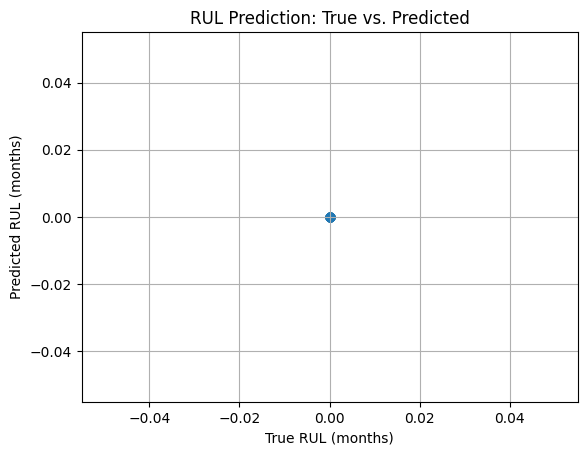

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Split data for training/testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred = rf_reg.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Optional: Plot predicted vs. true RUL
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("True RUL (months)")
plt.ylabel("Predicted RUL (months)")
plt.title("RUL Prediction: True vs. Predicted")
plt.grid()
plt.show()


In [ ]:
seq_rows = []
for idx, row in df.iterrows():
    spot_id = row['Equipment']  # or another unique ID

    # Safely convert time columns data to numeric, forcing errors to NaN and fill with 0
    vibration_values = pd.to_numeric(row[time_cols], errors='coerce').fillna(0).values

    for t in range(len(time_cols)):
        current_features = {
            'spot_id': spot_id,
            'month': time_cols[t],
            # Per-month vibration cleaned
            'vibration': vibration_values[t],
            # Static/spot features
            'flatline_pct': row['flatline_pct'],
            'trend_slope': row['trend_slope'],
            'trend_r2': row['trend_r2'],
            'rolling_std_12': row['rolling_std_12'],
            'recent_recovery': row['recent_recovery'],
            'Total Average': row['Total Average'],
            'Status': row['Status']
        }
        # Find months until next event safely
        future_events = np.where(vibration_values[t+1:] > 0)[0]
        if len(future_events):
            rul = future_events[0] + 1
        else:
            rul = len(time_cols) - t
        current_features['RUL'] = rul
        seq_rows.append(current_features)

seq_df = pd.DataFrame(seq_rows)
print("Sample rows after fixing NaN issue:")
print(seq_df.head(10))


Sample rows after fixing NaN issue:
                  spot_id     month  vibration  flatline_pct  trend_slope  \
0  1.1:COAL CONVEYOR CC-1  2019-Apr    2.18000           0.0     0.011178   
1  1.1:COAL CONVEYOR CC-1  2019-May    1.78000           0.0     0.011178   
2  1.1:COAL CONVEYOR CC-1  2019-Jun    1.99000           0.0     0.011178   
3  1.1:COAL CONVEYOR CC-1  2019-Jul    1.88000           0.0     0.011178   
4  1.1:COAL CONVEYOR CC-1  2019-Aug    2.30000           0.0     0.011178   
5  1.1:COAL CONVEYOR CC-1  2019-Sep    1.30000           0.0     0.011178   
6  1.1:COAL CONVEYOR CC-1  2019-Oct    3.84223           0.0     0.011178   
7  1.1:COAL CONVEYOR CC-1  2019-Nov    1.36000           0.0     0.011178   
8  1.1:COAL CONVEYOR CC-1  2019-Dec    1.53000           0.0     0.011178   
9  1.1:COAL CONVEYOR CC-1  2020-Jan    1.40000           0.0     0.011178   

   trend_r2  rolling_std_12  recent_recovery  Total Average Status  RUL  
0  0.052109        0.997591         0.8319

In [ ]:
features = [
    'vibration', 'flatline_pct', 'trend_slope', 'trend_r2', 'rolling_std_12',
    'recent_recovery', 'Total Average'
]

X_seq = seq_df[features]
y_seq = seq_df['RUL']
print("Sample features shape:", X_seq.shape)
print("Sample features (first 5 rows):")
print(X_seq.head())
print("Sample targets (RUL, first 5 rows):")
print(y_seq.head())


Sample features shape: (35568, 7)
Sample features (first 5 rows):
   vibration  flatline_pct  trend_slope  trend_r2  rolling_std_12  \
0       2.18           0.0     0.011178  0.052109        0.997591   
1       1.78           0.0     0.011178  0.052109        0.997591   
2       1.99           0.0     0.011178  0.052109        0.997591   
3       1.88           0.0     0.011178  0.052109        0.997591   
4       2.30           0.0     0.011178  0.052109        0.997591   

   recent_recovery  Total Average  
0         0.831976       2.358948  
1         0.831976       2.358948  
2         0.831976       2.358948  
3         0.831976       2.358948  
4         0.831976       2.358948  
Sample targets (RUL, first 5 rows):
0    1
1    1
2    1
3    1
4    1
Name: RUL, dtype: int64


Mean Absolute Error (MAE): 0.000
R2 Score: 0.000


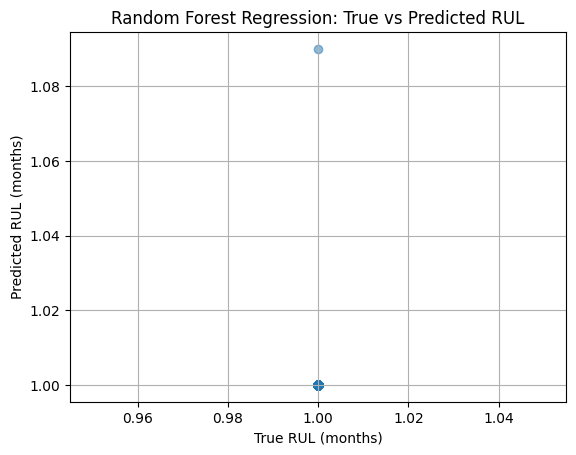

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Splitting (you could also consider time-based splits)
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

# Model training
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Predictions & evaluation
y_pred = rf_reg.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"R2 Score: {r2:.3f}")

# Optional: Plot true vs predicted RUL
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('True RUL (months)')
plt.ylabel('Predicted RUL (months)')
plt.title('Random Forest Regression: True vs Predicted RUL')
plt.grid(True)
plt.show()


In [ ]:
importances = rf_reg.feature_importances_
for f, imp in zip(features, importances):
    print(f"{f}: {imp:.3f}")


vibration: 0.091
flatline_pct: 0.858
trend_slope: 0.005
trend_r2: 0.012
rolling_std_12: 0.026
recent_recovery: 0.004
Total Average: 0.004


To improve accuracy

In [ ]:
import numpy as np

def max_flatline_run(row):
    # longest consecutive sequence of zeros
    arr = (row == 0).astype(int)
    max_run = 0
    current_run = 0
    for val in arr:
        if val == 1:
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 0
    return max_run

# Per spot flatline longest run
df['max_flatline_run'] = df[time_cols].apply(max_flatline_run, axis=1)

# Rolling averages and std deviations at multiple windows
for w in [3,6,12]:
    df[f'rolling_mean_{w}'] = df[time_cols].transpose().rolling(window=w).mean().transpose().mean(axis=1)
    df[f'rolling_std_{w}'] = df[time_cols].transpose().rolling(window=w).std().transpose().mean(axis=1)

print(df[[ 'max_flatline_run', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6']].head())


   max_flatline_run  rolling_mean_3  rolling_std_3  rolling_mean_6  \
0                 7        1.785662       0.831973        1.772920   
1                 3        4.419383       1.293409        4.417244   
2                 2        4.720824       1.436576        4.706423   
3                 6        3.379550       1.238971        3.356056   
4                 7        4.269860       1.424756        4.304737   

   rolling_std_6  
0       1.021172  
1       1.589059  
2       1.615116  
3       1.555614  
4       1.805349  


to improve accuracy


In [ ]:
import numpy as np

def max_flatline_run(row):
    # longest consecutive sequence of zeros
    arr = (row == 0).astype(int)
    max_run = 0
    current_run = 0
    for val in arr:
        if val == 1:
            current_run += 1
            max_run = max(max_run, current_run)
        else:
            current_run = 0
    return max_run

# Per spot flatline longest run
df['max_flatline_run'] = df[time_cols].apply(max_flatline_run, axis=1)

# Rolling averages and std deviations at multiple windows
for w in [3,6,12]:
    df[f'rolling_mean_{w}'] = df[time_cols].transpose().rolling(window=w).mean().transpose().mean(axis=1)
    df[f'rolling_std_{w}'] = df[time_cols].transpose().rolling(window=w).std().transpose().mean(axis=1)

print(df[[ 'max_flatline_run', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6']].head())


   max_flatline_run  rolling_mean_3  rolling_std_3  rolling_mean_6  \
0                 7        1.785662       0.831973        1.772920   
1                 3        4.419383       1.293409        4.417244   
2                 2        4.720824       1.436576        4.706423   
3                 6        3.379550       1.238971        3.356056   
4                 7        4.269860       1.424756        4.304737   

   rolling_std_6  
0       1.021172  
1       1.589059  
2       1.615116  
3       1.555614  
4       1.805349  


In [ ]:
# Drop 'vibration' from df feature extraction/merge step
# Use only features that exist in df for merging
df_features = [
    'flatline_pct', 'max_flatline_run', 'trend_slope', 'trend_r2', 'rolling_std_12',
    'recent_recovery', 'Total Average',
    'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6'
]

seq_df = seq_df.merge(
    df[['Equipment'] + df_features],
    left_on='spot_id', right_on='Equipment',
    how='left'
)

# Now include 'vibration' + merged features
features = [
    'vibration',  # per-row from seq_df, DO NOT merge from df!
    'flatline_pct', 'max_flatline_run', 'trend_slope', 'trend_r2', 'rolling_std_12',
    'recent_recovery', 'Total Average',
    'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6'
]

X_seq = seq_df[features]
y_seq = seq_df['RUL']
print(X_seq.head())



KeyError: "['flatline_pct', 'trend_slope', 'trend_r2', 'rolling_std_12', 'recent_recovery', 'Total Average'] not in index"

MAE: 7.121
R2 Score: 0.591


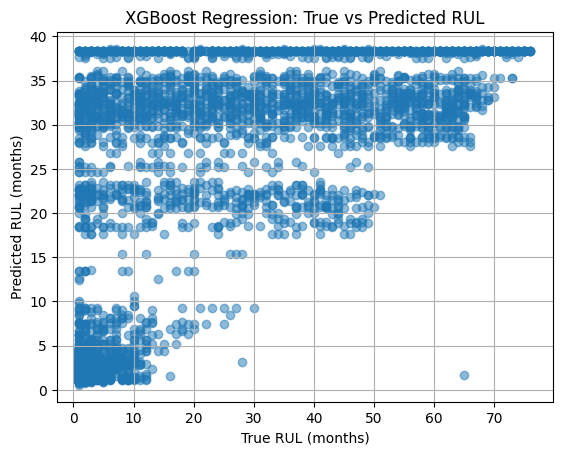

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200, max_depth=6, learning_rate=0.1)
xgb_reg.fit(X_train, y_train)

y_pred = xgb_reg.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.3f}")

# Plot predicted vs true
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('True RUL (months)')
plt.ylabel('Predicted RUL (months)')
plt.title('XGBoost Regression: True vs Predicted RUL')
plt.grid(True)
plt.show()


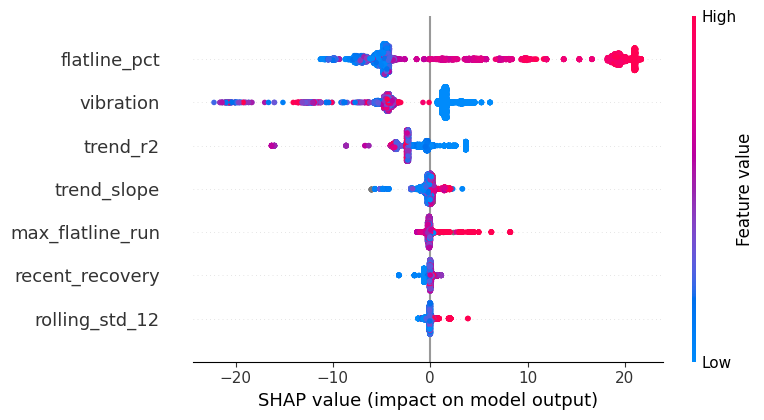

In [ ]:
import shap

explainer = shap.Explainer(xgb_reg)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features)


In [ ]:
# Rolling statistics at several windows
for w in [3, 6, 12]:
    seq_df[f'rolling_mean_{w}'] = seq_df.groupby('spot_id')['vibration'].transform(lambda x: x.rolling(w, min_periods=1).mean())
    seq_df[f'rolling_std_{w}'] = seq_df.groupby('spot_id')['vibration'].transform(lambda x: x.rolling(w, min_periods=1).std())

# Exponential weighted averages (trend sensitivity)
seq_df['ewm_mean_6'] = seq_df.groupby('spot_id')['vibration'].transform(lambda x: x.ewm(span=6, adjust=False).mean())


In [ ]:
# Rolling statistics at several windows
for w in [3, 6, 12]:
    seq_df[f'rolling_mean_{w}'] = seq_df.groupby('spot_id')['vibration'].transform(lambda x: x.rolling(w, min_periods=1).mean())
    seq_df[f'rolling_std_{w}'] = seq_df.groupby('spot_id')['vibration'].transform(lambda x: x.rolling(w, min_periods=1).std())

# Exponential weighted averages (trend sensitivity)
seq_df['ewm_mean_6'] = seq_df.groupby('spot_id')['vibration'].transform(lambda x: x.ewm(span=6, adjust=False).mean())


In [ ]:
from sklearn.feature_selection import RFECV
from xgboost import XGBRegressor

X = seq_df.drop(columns=['spot_id', 'month', 'Status', 'RUL'])  # drop non-features
y = seq_df['RUL']

model = XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.07)
rfecv = RFECV(estimator=model, step=1, cv=5, scoring='r2')
rfecv.fit(X.fillna(0), y)

print("Optimal features:", X.columns[rfecv.support_])
X_selected = X.loc[:, rfecv.support_]
# Drop non-numeric columns before modeling
non_numeric_cols = ['spot_id', 'month', 'Status']  # adjust as per your df
X_numeric = X.drop(columns=non_numeric_cols, errors='ignore')

# Fill any NaNs still present
X_numeric = X_numeric.fillna(0)

# Now fit RFECV on numeric data only
rfecv.fit(X_numeric, y)



ValueError: could not convert string to float: '1.1:COAL CONVEYOR CC-1'

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.07, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
}

xgb_reg = XGBRegressor()
search = RandomizedSearchCV(xgb_reg, param_grid, n_iter=25, scoring='r2', cv=5)
search.fit(X_selected, y)
print("Best parameters:", search.best_params_)


In [ ]:
from sklearn.model_selection import cross_val_score

model_best = search.best_estimator_
cv_scores = cross_val_score(model_best, X_selected.fillna(0), y, cv=5, scoring='r2')
print("Cross-validated R² scores:", cv_scores)
print("Average R²:", cv_scores.mean())
